# 📉 Options to Reduce Noise in SalesTeam AI Models

This notebook details techniques for detecting and removing noisy features in our recommendation models to avoid overfitting and ensure robust predictions on unseen clients.

---

## 🔍 Option A — Check feature importance first (do this before anything)

Checking feature importance helps identify:
1. **Uninformative Features**: Features with importance near 0 that only add noise to the splits.
2. **Overfitting Leakage**: Geographic features (like `latitude`/`longitude`) having abnormally high importance, meaning the model might be memorizing regions rather than purchasing behaviors.

=== Top Features ===
frequency                 0.642448
total_qty                 0.261777
avg_qty                   0.045715
avg_delay_days            0.020129
recency_days              0.010742
std_qty                   0.004752
recency_relative          0.002060
min_qty                   0.001390
best_month                0.001382
avg_seasonal_coef         0.001381
max_qty                   0.000872
days_since_first_order    0.000835
trend                     0.000824
client_avg_basket_size    0.000780
latitude                  0.000766
client_total_products     0.000759
last_qty                  0.000690
longitude                 0.000576
client_total_invoices     0.000543
nb_clients                0.000524
categorie_encoded         0.000375
has_gps                   0.000308
is_new_product            0.000266
is_bulk_product           0.000105
company_encoded           0.000000
current_month_coef        0.000000
dtype: float32


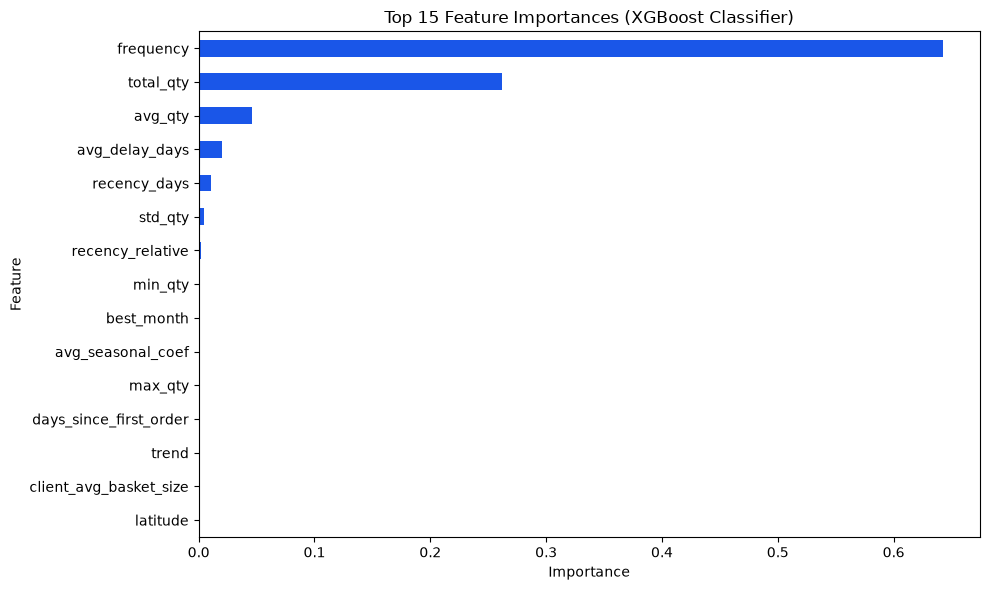


⚠️ Near-zero importance features (Noise candidates):
['max_qty', 'days_since_first_order', 'trend', 'client_avg_basket_size', 'latitude', 'client_total_products', 'last_qty', 'longitude', 'client_total_invoices', 'nb_clients', 'categorie_encoded', 'has_gps', 'is_new_product', 'is_bulk_product', 'company_encoded', 'current_month_coef']


In [3]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import json

# 1. Load the trained classifier model and metadata
model_path = '../models/classifier_lsat.joblib'
metadata_path = '../src/models/classifier_lsat_metadata.json'

# Fallback to project root paths if not running in notebooks directory context
if not os.path.exists(model_path):
    model_path = 'models/classifier_lsat.joblib'
    metadata_path = 'src/models/classifier_lsat_metadata.json'

if os.path.exists(model_path) and os.path.exists(metadata_path):
    model = joblib.load(model_path)
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    
    feature_names = metadata.get('feature_columns', [])
    importances = model.feature_importances_

    # Create a Series of importances sorted descending
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("=== Top Features ===")
    print(fi.head(29))

    # Plot feature importances
    plt.figure(figsize=(10, 6))
    fi.head(15).plot(kind='barh', color='#1a56e8')
    plt.gca().invert_yaxis()
    plt.title('Top 15 Feature Importances (XGBoost Classifier)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    # Warnings about noise
    near_zero = fi[fi < 0.001]
    if not near_zero.empty:
        print("\n⚠️ Near-zero importance features (Noise candidates):")
        print(near_zero.index.tolist())
else:
    print("Trained model classifier_lsat.joblib or metadata not found. Please train the model first.")

## 🌍 Option B — Analyze Geographical Overfitting

If `latitude` or `longitude` has high importance, the model might recommend products based on geographic location rather than product preferences. This is a common pitfall when dataset coordinates have high correlation with client clusters.

### Strategy:
- If geography has high importance: Retrain the model *without* `latitude` and `longitude` and verify if test ROC-AUC remains high (ideal for clean generalization).

In [ ]:
# Check GPS relative importance compared to history
if 'fi' in locals():
    gps_importance = fi.get('latitude', 0.0) + fi.get('longitude', 0.0)
    history_importance = fi.get('frequency', 0.0) + fi.get('total_qty', 0.0)
    
    print(f"Total GPS Features Importance: {gps_importance:.4f}")
    print(f"Total Historical Behavior Importance: {history_importance:.4f}")
    
    if gps_importance > 0.10:
        print("\n🔴 WARNING: GPS features have more than 10% importance. The model might be overfitting to geography.")
    else:
        print("\n🟢 OK: GPS features have low importance, suggesting minimal geographic overfitting.")